In [1]:
import os, re, json, itertools, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (precision_recall_curve, roc_auc_score,
                             average_precision_score, precision_score,
                             recall_score, f1_score)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

DATA_DIR = "../dataset"
RES_DIR = "results"
os.makedirs(RES_DIR, exist_ok=True)

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 200)

In [2]:
df = pd.read_csv(f"{DATA_DIR}/train.csv")   # sirf train.csv me labels hain
print(df.shape)

def clean_title(s):
    s = unicodedata.normalize("NFKC", str(s)).lower()
    s = re.sub(r"http\S+", " ", s)
    s = re.sub(r"[^\w\s]|_", " ", s)        # punctuation/emoji hatao, digits aur letters (CJK bhi) rakho
    return re.sub(r"\s+", " ", s).strip()

df["title_clean"] = df["title"].map(clean_title)
df["tok"] = df["title_clean"].str.split().map(set)
df["nums"] = df["title_clean"].map(lambda s: set(re.findall(r"\d+", s)))
df["n_words"] = df["title_clean"].str.split().str.len()

print("Empty cleaned titles:", (df["title_clean"] == "").sum())
df[["title", "title_clean"]].sample(5, random_state=SEED)

(34250, 5)
Empty cleaned titles: 0


,title,title_clean
18637,Creamer Nabati (Non Dairy Creamer) Premium & Reguler 1 Kg,creamer nabati non dairy creamer premium reguler 1 kg
12463,Chek Hup 3 in 1 Ipoh White Coffee King 40gr x 15,chek hup 3 in 1 ipoh white coffee king 40gr x 15
30555,( 27AN.ID) COD Kacamata Hitam KM50 Gaya Steampunk Vintage Bentuk Kotak Gaya Harajuku,27an id cod kacamata hitam km50 gaya steampunk vintage bentuk kotak gaya harajuku
20772,Sapu Mini + Cikrak Sebaguna (Paket Hemat),sapu mini cikrak sebaguna paket hemat
12240,SARUNG TANGAN IGLOVE TOUCH SCREEN HP ANDROID GOJEK GRAB,sarung tangan iglove touch screen hp android gojek grab


In [3]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
trv_idx, te_idx = next(gss1.split(df, groups=df["label_group"]))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
tr_rel, va_rel = next(gss2.split(df.iloc[trv_idx], groups=df["label_group"].iloc[trv_idx]))
tr_idx, va_idx = trv_idx[tr_rel], trv_idx[va_rel]

df["split"] = "train"
df.loc[va_idx, "split"] = "val"
df.loc[te_idx, "split"] = "test"

summ = df.groupby("split").agg(listings=("posting_id", "size"), groups=("label_group", "nunique"))
display(summ)

g = {s: set(df.loc[df.split == s, "label_group"]) for s in ["train", "val", "test"]}
print("Group overlap train/val:", len(g["train"] & g["val"]),
      "| train/test:", len(g["train"] & g["test"]),
      "| val/test:", len(g["val"] & g["test"]))   # teeno 0 hone chahiye

,listings,groups
split,,
test,7062,2203
train,20288,6608
val,6900,2203


Group overlap train/val: 0 | train/test: 0 | val/test: 0


In [4]:
def make_pairs(idx_pool, seed, max_pos_per_group=3, neg_ratio=1.0, hard_frac=0.5):
    """Positives: same label_group. Negatives: random + hard (alag group, sabse similar title)."""
    rng = np.random.default_rng(seed)
    labels = df["label_group"].values
    pool = np.asarray(idx_pool)
    sub = df.loc[pool]

    # ---- positives ----
    pos = set()
    for lbl, members in sub.groupby("label_group").groups.items():
        allp = list(itertools.combinations(list(members), 2))
        if len(allp) > max_pos_per_group:
            sel = rng.choice(len(allp), max_pos_per_group, replace=False)
            allp = [allp[i] for i in sel]
        pos.update(allp)
    pos = list(pos)

    n_neg = int(len(pos) * neg_ratio)
    n_hard = int(n_neg * hard_frac)
    n_rand = n_neg - n_hard

    # ---- random negatives ----
    rand = set()
    while len(rand) < n_rand:
        a, b = rng.choice(pool, 2, replace=False)
        if labels[a] != labels[b]:
            rand.add((min(a, b), max(a, b)))
    rand = list(rand)

    # ---- hard negatives: isi pool me word-TF-IDF se sabse similar, par alag group ----
    tf = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", sublinear_tf=True)
    Xp = tf.fit_transform(df.loc[pool, "title_clean"])
    lp = labels[pool]
    hard = set()
    order = rng.permutation(len(pool))
    for s in range(0, len(order), 500):
        if len(hard) >= n_hard:
            break
        a = order[s:s + 500]
        S = (Xp[a] @ Xp.T).toarray()
        S[lp[a][:, None] == lp[None, :]] = -1            # same group aur self exclude
        top = np.argpartition(-S, 5, axis=1)[:, :5]
        pick = top[np.arange(len(a)), rng.integers(0, 5, len(a))]
        for ai, pi in zip(a, pick):
            x, y = pool[ai], pool[pi]
            hard.add((min(x, y), max(x, y)))
    hard = list(hard)
    rng.shuffle(hard)
    hard = hard[:n_hard]

    rows = ([(a, b, 1, "pos") for a, b in pos] +
            [(a, b, 0, "rand_neg") for a, b in rand] +
            [(a, b, 0, "hard_neg") for a, b in hard])
    P = pd.DataFrame(rows, columns=["a", "b", "y", "kind"])
    P = P.sample(frac=1, random_state=seed).reset_index(drop=True)
    for side in ["a", "b"]:
        P[f"title_{side}"] = df["title"].values[P[side].values]
        P[f"clean_{side}"] = df["title_clean"].values[P[side].values]
        P[f"grp_{side}"] = labels[P[side].values]
    return P

P_train = make_pairs(tr_idx, SEED)
P_val = make_pairs(va_idx, SEED + 1)
P_test = make_pairs(te_idx, SEED + 2)

for n, P in [("train", P_train), ("val", P_val), ("test", P_test)]:
    print(n, len(P), P["kind"].value_counts().to_dict())
P_val.head()

train 22668 {'pos': 11334, 'rand_neg': 5667, 'hard_neg': 5667}
val 7726 {'pos': 3863, 'rand_neg': 1932, 'hard_neg': 1931}
test 7774 {'pos': 3887, 'rand_neg': 1944, 'hard_neg': 1943}


,a,b,y,kind,title_a,clean_a,grp_a,title_b,clean_b,grp_b
0,6603,23280,1,pos,Audio Splitter 1 Input 2 Output Share Music For 2 Headset Jack 3.5mm,audio splitter 1 input 2 output share music for 2 headset jack 3 5mm,770757360,Carda} Kabel Adapter Splitter AUX Audio Mic 3.5mm Male ke Female untuk Earphone,carda kabel adapter splitter aux audio mic 3 5mm male ke female untuk earphone,770757360
1,7093,11280,0,hard_neg,Miss Blossom,miss blossom,3653322420,100% ORIGINAL JUST MISS EYEBROW PENCIL,100 original just miss eyebrow pencil,3198306492
2,7511,26211,1,pos,SEPATU PATROBAS EQUIP BLACK WHITE LOW,sepatu patrobas equip black white low,3022813665,Sepatu Patrobas Equip Low Black White,sepatu patrobas equip low black white,3022813665
3,14612,30127,1,pos,Sarung Tangan Karet / Latex Freder (size M) Sarung Tangan Cuci Piring,sarung tangan karet latex freder size m sarung tangan cuci piring,2065465349,SARUNG TANGAN KARET KENMASTER / FREEDER ORI100% LENTUR/ SERBAGUNA CEGAH ANTI BAKTERI CUCI PELINDUNG,sarung tangan karet kenmaster freeder ori100 lentur serbaguna cegah anti bakteri cuci pelindung,2065465349
4,17456,33083,1,pos,POLYFLEX PVC MURAH (KODE 1-15) - best seller,polyflex pvc murah kode 1 15 best seller,4196686200,Polyflex PVC Korea Original / PVC Murah / Bahan Sablon /,polyflex pvc korea original pvc murah bahan sablon,4196686200


In [5]:
yv, yt = P_val["y"].values, P_test["y"].values
m_rand_v = (P_val["kind"] != "hard_neg").values
m_hard_v = (P_val["kind"] != "rand_neg").values
m_rand_t = (P_test["kind"] != "hard_neg").values
m_hard_t = (P_test["kind"] != "rand_neg").values

def cos_sparse(M, a, b):          # TF-IDF rows L2-normalised hain, to dot = cosine
    return np.asarray(M[a].multiply(M[b]).sum(axis=1)).ravel()

def cos_dense(E, a, b):           # embeddings normalised
    return (E[a] * E[b]).sum(1)

def best_threshold(y, s):
    p, r, t = precision_recall_curve(y, s)
    f1 = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-12)
    i = int(np.argmax(f1))
    return t[i], f1[i]

RESULTS, SCORES = [], {}

def add_result(exp, rep, sim, sv, st):
    thr, f1v = best_threshold(yv, sv)          # threshold SIRF val par tune hota hai
    pred = st >= thr
    RESULTS.append(dict(
        Experiment=exp, Representation=rep, Similarity=sim,
        Threshold=round(float(thr), 3), Val_F1=round(f1v, 4),
        Test_P=round(precision_score(yt, pred), 4), Test_R=round(recall_score(yt, pred), 4),
        Test_F1=round(f1_score(yt, pred), 4),
        Test_AUC=round(roc_auc_score(yt, st), 4), Test_AP=round(average_precision_score(yt, st), 4),
        AP_randneg=round(average_precision_score(yt[m_rand_t], st[m_rand_t]), 4),
        AP_hardneg=round(average_precision_score(yt[m_hard_t], st[m_hard_t]), 4)))
    SCORES[exp] = {"val": sv, "test": st}
    return pd.DataFrame(RESULTS).tail(1)

def fit_tfidf(**kw):
    vec = TfidfVectorizer(sublinear_tf=True, **kw)
    vec.fit(df.loc[tr_idx, "title_clean"])        # vocabulary/IDF sirf train se
    return vec, vec.transform(df["title_clean"])

In [6]:
vec_w, M_word = fit_tfidf(token_pattern=r"(?u)\b\w+\b", ngram_range=(1, 1))
sv = cos_sparse(M_word, P_val["a"].values, P_val["b"].values)
st = cos_sparse(M_word, P_test["a"].values, P_test["b"].values)
print("Vocabulary size:", len(vec_w.vocabulary_))
add_result("Baseline TF-IDF", "TF-IDF word 1-gram", "Cosine", sv, st)

Vocabulary size: 18572


,Experiment,Representation,Similarity,Threshold,Val_F1,Test_P,Test_R,Test_F1,Test_AUC,Test_AP,AP_randneg,AP_hardneg
0,Baseline TF-IDF,TF-IDF word 1-gram,Cosine,0.337,0.8063,0.7859,0.8179,0.8016,0.8848,0.8922,0.9892,0.8976


In [7]:
configs = {
    "word 1-gram":   dict(token_pattern=r"(?u)\b\w+\b", ngram_range=(1, 1)),
    "word 1-2gram":  dict(token_pattern=r"(?u)\b\w+\b", ngram_range=(1, 2)),
    "char_wb 2-4":   dict(analyzer="char_wb", ngram_range=(2, 4), min_df=2),
    "char_wb 2-5":   dict(analyzer="char_wb", ngram_range=(2, 5), min_df=2),
    "char_wb 3-5":   dict(analyzer="char_wb", ngram_range=(3, 5), min_df=2),
}
abl, MATS = [], {}
for name, kw in configs.items():
    vec, M = fit_tfidf(**kw)
    MATS[name] = M
    sv = cos_sparse(M, P_val["a"].values, P_val["b"].values)
    _, f1v = best_threshold(yv, sv)
    abl.append(dict(config=name, n_features=len(vec.vocabulary_), val_F1=round(f1v, 4),
                    val_AP=round(average_precision_score(yv, sv), 4),
                    val_AP_hardneg=round(average_precision_score(yv[m_hard_v], sv[m_hard_v]), 4)))
abl = pd.DataFrame(abl)
abl

,config,n_features,val_F1,val_AP,val_AP_hardneg
0,word 1-gram,18572,0.8063,0.8920,0.8960
1,word 1-2gram,105749,0.8039,0.8895,0.8936
2,char_wb 2-4,34202,0.8401,0.9177,0.9186
3,char_wb 2-5,64345,0.8373,0.9154,0.9164
4,char_wb 3-5,63095,0.8360,0.9141,0.9150


In [8]:
def register(cfg_name, exp, rep):
    M = MATS[cfg_name]
    sv = cos_sparse(M, P_val["a"].values, P_val["b"].values)
    st = cos_sparse(M, P_test["a"].values, P_test["b"].values)
    return add_result(exp, rep, "Cosine", sv, st)

best_char = abl[abl.config.str.startswith("char")].sort_values("val_F1").iloc[-1]["config"]
print("Best char config (by val F1):", best_char)

register("word 1-2gram", "Exp1a TF-IDF word 1-2gram", "TF-IDF word 1-2gram")
register(best_char, "Exp1b TF-IDF char n-gram", f"TF-IDF {best_char}")
M_char = MATS[best_char]

Best char config (by val F1): char_wb 2-4


In [10]:
%pip install -q sentence-transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: c:\Users\shrey\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [11]:
from sentence_transformers import SentenceTransformer
import torch

EMB_PATH = f"{RES_DIR}/emb_minilm_multilingual.npy"
if os.path.exists(EMB_PATH):
    E = np.load(EMB_PATH)
else:
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=dev)
    E = model.encode(df["title_clean"].tolist(), batch_size=128,
                     show_progress_bar=True, normalize_embeddings=True)
    np.save(EMB_PATH, E)
print("Embeddings:", E.shape)

Batches: 100%|██████████| 268/268 [04:19<00:00,  1.03it/s]


Embeddings: (34250, 384)


In [19]:
sv = cos_dense(E, P_val["a"].values, P_val["b"].values)
st = cos_dense(E, P_test["a"].values, P_test["b"].values)
add_result("Exp2 Sentence embeddings", "paraphrase-multilingual-MiniLM-L12-v2 (zero-shot)", "Cosine", sv, st)

,Experiment,Representation,Similarity,Threshold,Val_F1,Test_P,Test_R,Test_F1,Test_AUC,Test_AP,AP_randneg,AP_hardneg
4,Exp2 Sentence embeddings,paraphrase-multilingual-MiniLM-L12-v2 (zero-shot),Cosine,0.49,0.8198,0.7413,0.8907,0.8092,0.8885,0.8873,0.9922,0.8913


In [20]:
## Hybrid
def pair_sc(split):
    P = P_val if split == "val" else P_test
    a, b = P["a"].values, P["b"].values
    return (cos_sparse(M_word, a, b), cos_sparse(M_char, a, b), cos_dense(E, a, b))

vw, vc, ve = pair_sc("val")
tw, tc, te = pair_sc("test")

grid = []
for i in range(11):
    for j in range(11 - i):
        w = (i / 10, j / 10, (10 - i - j) / 10)
        s = w[0] * vw + w[1] * vc + w[2] * ve
        _, f1v = best_threshold(yv, s)
        grid.append((*w, f1v))
grid = pd.DataFrame(grid, columns=["w_word", "w_char", "w_emb", "val_F1"]).sort_values("val_F1", ascending=False)
display(grid.head(5))

bw = grid.iloc[0]
W = (bw.w_word, bw.w_char, bw.w_emb)
print("Chosen weights (word, char, emb):", W)
add_result("Exp3 Hybrid", f"Weighted sum word/char/emb {W}", "Weighted cosine",
           W[0] * vw + W[1] * vc + W[2] * ve, W[0] * tw + W[1] * tc + W[2] * te)

,w_word,w_char,w_emb,val_F1
8,0.0,0.8,0.2,0.840962
9,0.0,0.9,0.1,0.840208
10,0.0,1.0,0.0,0.840069
7,0.0,0.7,0.3,0.840039
19,0.1,0.8,0.1,0.839726


Chosen weights (word, char, emb): (np.float64(0.0), np.float64(0.8), np.float64(0.2))


,Experiment,Representation,Similarity,Threshold,Val_F1,Test_P,Test_R,Test_F1,Test_AUC,Test_AP,AP_randneg,AP_hardneg
5,Exp3 Hybrid,"Weighted sum word/char/emb (np.float64(0.0), np.float64(0.8), np.float64(0.2))",Weighted cosine,0.382,0.841,0.787,0.8829,0.8322,0.9175,0.9181,0.9979,0.9191


In [22]:
def jaccard(a, b):
    u = len(a | b)
    return len(a & b) / u if u else 0.0

tok = df["tok"].values

In [23]:
## Learned Matcher

nums = df["nums"].values
nw = df["n_words"].values

def pair_features(P):
    a, b = P["a"].values, P["b"].values
    f = pd.DataFrame({
        "cos_word": cos_sparse(M_word, a, b),
        "cos_char": cos_sparse(M_char, a, b),
        "cos_emb": cos_dense(E, a, b),
        "jaccard": [jaccard(tok[i], tok[j]) for i, j in zip(a, b)],
        "len_ratio": [min(nw[i], nw[j]) / max(nw[i], nw[j], 1) for i, j in zip(a, b)],
        "num_jaccard": [jaccard(nums[i], nums[j]) if (nums[i] or nums[j]) else 1.0 for i, j in zip(a, b)],
        "num_conflict": [int(bool(nums[i]) and bool(nums[j]) and nums[i] != nums[j]) for i, j in zip(a, b)],
    })
    return f

F_train, F_val, F_test = pair_features(P_train), pair_features(P_val), pair_features(P_test)

clf = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000))
clf.fit(F_train, P_train["y"])

coef = pd.Series(clf[-1].coef_[0], index=F_train.columns).sort_values()
print("Standardised coefficients:\n", coef.round(3))

add_result("Exp4 LogReg on pair features", "7 pair features (cosines + numeric + length)", "LR probability",
           clf.predict_proba(F_val)[:, 1], clf.predict_proba(F_test)[:, 1])

Standardised coefficients:
 cos_word       -1.175
num_conflict   -0.163
len_ratio      -0.120
num_jaccard     0.185
jaccard         0.278
cos_emb         0.627
cos_char        2.255
dtype: float64


,Experiment,Representation,Similarity,Threshold,Val_F1,Test_P,Test_R,Test_F1,Test_AUC,Test_AP,AP_randneg,AP_hardneg
6,Exp4 LogReg on pair features,7 pair features (cosines + numeric + length),LR probability,0.299,0.8465,0.7702,0.9053,0.8323,0.9197,0.9193,0.9975,0.9205


,Experiment,Representation,Similarity,Threshold,Val_F1,Test_P,Test_R,Test_F1,Test_AUC,Test_AP,AP_randneg,AP_hardneg
0,Baseline TF-IDF,TF-IDF word 1-gram,Cosine,0.337,0.8063,0.7859,0.8179,0.8016,0.8848,0.8922,0.9892,0.8976
1,Exp1a TF-IDF word 1-2gram,TF-IDF word 1-2gram,Cosine,0.257,0.8039,0.7874,0.8024,0.7949,0.8799,0.8863,0.9891,0.8918
2,Exp1b TF-IDF char n-gram,TF-IDF char_wb 2-4,Cosine,0.351,0.8401,0.7946,0.8788,0.8346,0.9149,0.9167,0.9972,0.9180
3,Exp3 Hybrid,"Weighted sum word/char/emb (np.float64(0.0), np.float64(0.8), np.float64(0.2))",Weighted cosine,0.382,0.8410,0.7870,0.8829,0.8322,0.9175,0.9181,0.9979,0.9191
4,Exp2 Sentence embeddings,paraphrase-multilingual-MiniLM-L12-v2 (zero-shot),Cosine,0.490,0.8198,0.7413,0.8907,0.8092,0.8885,0.8873,0.9922,0.8913
5,Exp3 Hybrid,"Weighted sum word/char/emb (np.float64(0.0), np.float64(0.8), np.float64(0.2))",Weighted cosine,0.382,0.8410,0.7870,0.8829,0.8322,0.9175,0.9181,0.9979,0.9191
6,Exp4 LogReg on pair features,7 pair features (cosines + numeric + length),LR probability,0.299,0.8465,0.7702,0.9053,0.8323,0.9197,0.9193,0.9975,0.9205


,config,n_features,val_F1,val_AP,val_AP_hardneg
0,word 1-gram,18572,0.8063,0.8920,0.8960
1,word 1-2gram,105749,0.8039,0.8895,0.8936
2,char_wb 2-4,34202,0.8401,0.9177,0.9186
3,char_wb 2-5,64345,0.8373,0.9154,0.9164
4,char_wb 3-5,63095,0.8360,0.9141,0.9150


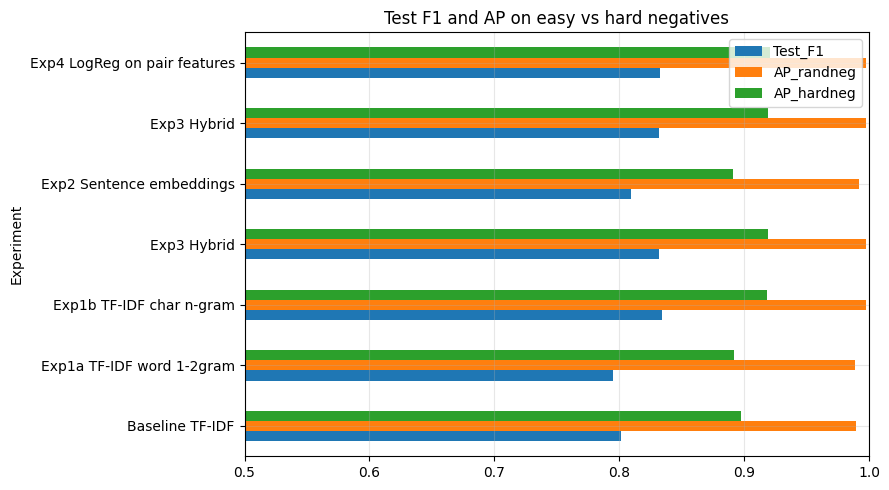

In [24]:
res = pd.DataFrame(RESULTS)
res.to_csv(f"{RES_DIR}/experiment_table.csv", index=False)
display(res)
display(abl)
abl.to_csv(f"{RES_DIR}/ablation_tfidf_configs.csv", index=False)

ax = res.set_index("Experiment")[["Test_F1", "AP_randneg", "AP_hardneg"]].plot.barh(figsize=(9, 5))
ax.set_title("Test F1 and AP on easy vs hard negatives"); ax.set_xlim(0.5, 1.0)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/experiment_comparison.png", dpi=150); plt.show()

In [25]:
def sim_mats(split_idx):
    Sw = (M_word[split_idx] @ M_word[split_idx].T).toarray().astype(np.float32)
    Sc = (M_char[split_idx] @ M_char[split_idx].T).toarray().astype(np.float32)
    Es = E[split_idx]
    Se = (Es @ Es.T).astype(np.float32)
    return Sw, Sc, Se

def retr_f1(S, true, thr):
    pred = S >= thr
    np.fill_diagonal(pred, True)                      # listing khud ko hamesha match karti hai
    inter = (pred & true).sum(1)
    return float(np.mean(2 * inter / (pred.sum(1) + true.sum(1))))

lab_v = df.loc[va_idx, "label_group"].values
lab_t = df.loc[te_idx, "label_group"].values
true_v = lab_v[:, None] == lab_v[None, :]
true_t = lab_t[:, None] == lab_t[None, :]

Sv3, St3 = sim_mats(va_idx), sim_mats(te_idx)
methods = {
    "TF-IDF word":  lambda S: S[0],
    "TF-IDF char":  lambda S: S[1],
    "Embeddings":   lambda S: S[2],
    "Hybrid":       lambda S: W[0] * S[0] + W[1] * S[1] + W[2] * S[2],
}
grid_thr = np.arange(0.2, 0.98, 0.04)
rows = []
for name, fn in methods.items():
    Sv, St = fn(Sv3), fn(St3)
    sc = [retr_f1(Sv, true_v, t) for t in grid_thr]
    bt = grid_thr[int(np.argmax(sc))]
    rows.append(dict(method=name, best_thr_val=round(bt, 2),
                     val_meanF1=round(max(sc), 4), test_meanF1=round(retr_f1(St, true_t, bt), 4)))
retr = pd.DataFrame(rows)
retr.to_csv(f"{RES_DIR}/retrieval_f1.csv", index=False)
retr

,method,best_thr_val,val_meanF1,test_meanF1
0,TF-IDF word,0.48,0.7441,0.7512
1,TF-IDF char,0.52,0.7783,0.7829
2,Embeddings,0.80,0.6562,0.6615
3,Hybrid,0.52,0.7787,0.7838


Final model: Exp4 LogReg on pair features
Val-tuned threshold = 0.299 (val F1 = 0.8465)


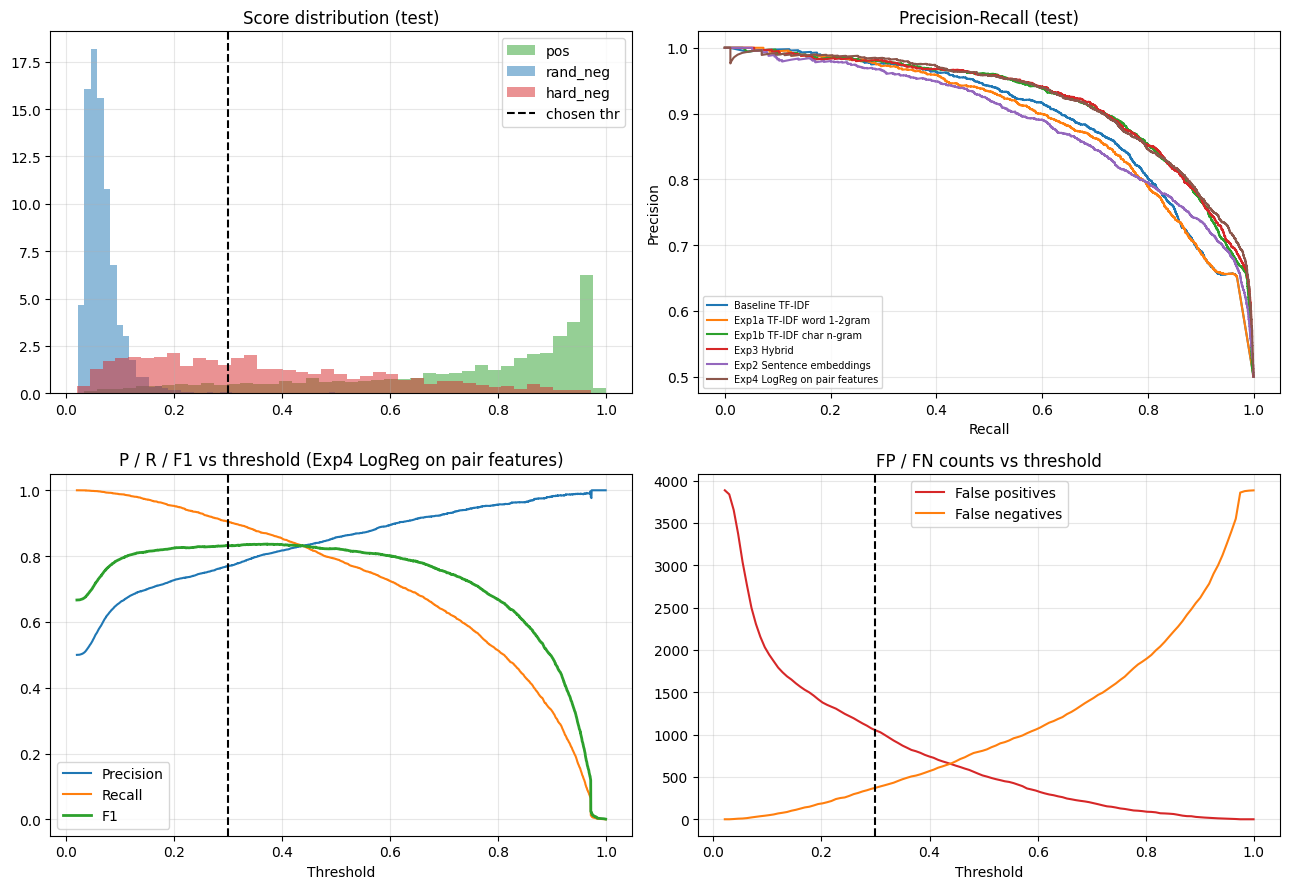

In [26]:
## Threshold Annalysis

final = res.sort_values("Val_F1").iloc[-1]["Experiment"]       # val F1 se choose
print("Final model:", final)
sv_f, st_f = SCORES[final]["val"], SCORES[final]["test"]
thr_f, f1_f = best_threshold(yv, sv_f)
print(f"Val-tuned threshold = {thr_f:.3f} (val F1 = {f1_f:.4f})")

p_t, r_t, t_t = precision_recall_curve(yt, st_f)
f1_curve = 2 * p_t[:-1] * r_t[:-1] / (p_t[:-1] + r_t[:-1] + 1e-12)

thr_grid = np.linspace(sv_f.min(), sv_f.max(), 120)
fp_c = np.array([((st_f >= t) & (yt == 0)).sum() for t in thr_grid])
fn_c = np.array([((st_f < t) & (yt == 1)).sum() for t in thr_grid])

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
# (a) score distributions
for kind, c in [("pos", "tab:green"), ("rand_neg", "tab:blue"), ("hard_neg", "tab:red")]:
    ax[0, 0].hist(st_f[(P_test["kind"] == kind).values], bins=40, alpha=0.5, density=True, label=kind, color=c)
ax[0, 0].axvline(thr_f, color="k", ls="--", label="chosen thr")
ax[0, 0].set_title("Score distribution (test)"); ax[0, 0].legend()
# (b) PR curves, sab methods
for name in SCORES:
    p, r, _ = precision_recall_curve(yt, SCORES[name]["test"])
    ax[0, 1].plot(r, p, label=name)
ax[0, 1].set_xlabel("Recall"); ax[0, 1].set_ylabel("Precision"); ax[0, 1].set_title("Precision-Recall (test)")
ax[0, 1].legend(fontsize=7)
# (c) P/R/F1 vs threshold
ax[1, 0].plot(t_t, p_t[:-1], label="Precision"); ax[1, 0].plot(t_t, r_t[:-1], label="Recall")
ax[1, 0].plot(t_t, f1_curve, label="F1", lw=2); ax[1, 0].axvline(thr_f, color="k", ls="--")
ax[1, 0].set_xlabel("Threshold"); ax[1, 0].set_title(f"P / R / F1 vs threshold ({final})"); ax[1, 0].legend()
# (d) FP vs FN
ax[1, 1].plot(thr_grid, fp_c, label="False positives", color="tab:red")
ax[1, 1].plot(thr_grid, fn_c, label="False negatives", color="tab:orange")
ax[1, 1].axvline(thr_f, color="k", ls="--")
ax[1, 1].set_xlabel("Threshold"); ax[1, 1].set_title("FP / FN counts vs threshold"); ax[1, 1].legend()
plt.tight_layout(); plt.savefig(f"{RES_DIR}/threshold_analysis.png", dpi=150); plt.show()

In [27]:
p_v, r_v, t_v = precision_recall_curve(yv, sv_f)
ops = {"Max F1 (chosen)": thr_f}
idx = np.where(p_v[:-1] >= 0.95)[0]
if len(idx): ops["High precision (val P>=0.95)"] = t_v[idx[0]]
idx = np.where(r_v[:-1] >= 0.95)[0]
if len(idx): ops["High recall (val R>=0.95)"] = t_v[idx[-1]]

rows = []
for name, t in ops.items():
    pred = st_f >= t
    rows.append(dict(operating_point=name, threshold=round(float(t), 3),
                     precision=round(precision_score(yt, pred), 4), recall=round(recall_score(yt, pred), 4),
                     f1=round(f1_score(yt, pred), 4),
                     false_pos=int((pred & (yt == 0)).sum()), false_neg=int((~pred & (yt == 1)).sum()),
                     FP_on_hard_neg=int((pred & (P_test["kind"] == "hard_neg").values).sum())))
thr_table = pd.DataFrame(rows)
thr_table.to_csv(f"{RES_DIR}/threshold_table.csv", index=False)
thr_table

,operating_point,threshold,precision,recall,f1,false_pos,false_neg,FP_on_hard_neg
0,Max F1 (chosen),0.299,0.7702,0.9053,0.8323,1050,368,1048
1,High precision (val P>=0.95),0.826,0.9626,0.4765,0.6374,72,2035,72
2,High recall (val R>=0.95),0.229,0.7368,0.9383,0.8254,1303,240,1297


In [28]:
P_test["score"] = st_f
P_test["pred"] = (st_f >= thr_f).astype(int)

def explain(r):
    ta, tb = set(r.clean_a.split()), set(r.clean_b.split())
    return (f"shared={sorted(ta & tb)[:10]} | only_A={sorted(ta - tb)[:8]} | only_B={sorted(tb - ta)[:8]}")

def show(P, header, n=5):
    print("=" * 110, f"\n{header}  (showing {min(n, len(P))} of {len(P)})\n" + "=" * 110)
    for _, r in P.head(n).iterrows():
        print(f"[{r.kind}] score={r.score:.3f} | true={'MATCH' if r.y else 'DIFFERENT'} | pred={'MATCH' if r.pred else 'DIFFERENT'}")
        print("  A:", r.title_a[:130]); print("  B:", r.title_b[:130])
        print("  ", explain(r), "\n")

TP = P_test[(P_test.pred == 1) & (P_test.y == 1)]
FP = P_test[(P_test.pred == 1) & (P_test.y == 0)]
FN = P_test[(P_test.pred == 0) & (P_test.y == 1)]
TN = P_test[(P_test.pred == 0) & (P_test.y == 0)]
print(f"TP={len(TP)}  FP={len(FP)}  FN={len(FN)}  TN={len(TN)}")

show(TP.sample(4, random_state=1), "CORRECT MATCH (True Positive), random")
show(TP.sort_values("score").head(3), "CORRECT MATCH, lowest-score true positives (barely caught)", 3)
show(FP.sort_values("score", ascending=False), "WRONG MATCH (False Positive), highest score first", 6)
show(FN.sort_values("score"), "MISSED MATCH (False Negative), lowest score first", 6)

TP=3519  FP=1050  FN=368  TN=2837
CORRECT MATCH (True Positive), random  (showing 4 of 4)
[pos] score=0.688 | true=MATCH | pred=MATCH
  A: NIVEA MEN CREME 30ML
  B: Nivea Men Creme Moisturizer 30-75 ml
   shared=['creme', 'men', 'nivea'] | only_A=['30ml'] | only_B=['30', '75', 'ml', 'moisturizer'] 

[pos] score=0.506 | true=MATCH | pred=MATCH
  A: SUDAH PAKAI DUS Sandal Anna Ivanovic mika flat AA
  B: Sandal flat mika samping
   shared=['flat', 'mika', 'sandal'] | only_A=['aa', 'anna', 'dus', 'ivanovic', 'pakai', 'sudah'] | only_B=['samping'] 

[pos] score=0.951 | true=MATCH | pred=MATCH
  A: FREE MASKER & BUBBLE WRAP!! JOK PORTABLE BONCENGAN MOTOR ANAK / JOK SADEL KURSI BONCENG MOTOR
  B: FREE MASKER & BUBBLE WRAP!! JOK PORTABLE PRINTING KURSI BONCENGAN MOTOR ANAK / JOK BONCENG MOTOR LOL
   shared=['anak', 'bonceng', 'boncengan', 'bubble', 'free', 'jok', 'kursi', 'masker', 'motor', 'portable'] | only_A=['sadel'] | only_B=['lol', 'printing'] 

[pos] score=0.638 | true=MATCH | pred=MATC

In [29]:
def num_conflict(r):
    na, nb = set(re.findall(r"\d+", r.clean_a)), set(re.findall(r"\d+", r.clean_b))
    return bool(na) and bool(nb) and na != nb

def has_cjk(s):
    return bool(re.search(r"[\u4e00-\u9fff]", s))

FP = FP.copy(); FN = FN.copy()
FP["num_conflict"] = FP.apply(num_conflict, axis=1)
FP["jaccard"] = FP.apply(lambda r: jaccard(set(r.clean_a.split()), set(r.clean_b.split())), axis=1)
FN["jaccard"] = FN.apply(lambda r: jaccard(set(r.clean_a.split()), set(r.clean_b.split())), axis=1)
FN["script_mismatch"] = FN.apply(lambda r: has_cjk(r.clean_a) != has_cjk(r.clean_b), axis=1)
FN["short_title"] = FN.apply(lambda r: min(len(r.clean_a.split()), len(r.clean_b.split())) <= 3, axis=1)

print("FALSE POSITIVES")
print(f"  from hard negatives           : {(FP.kind == 'hard_neg').mean():.1%}")
print(f"  numeric tokens conflict       : {FP.num_conflict.mean():.1%}")
print(f"  word Jaccard >= 0.5           : {(FP.jaccard >= 0.5).mean():.1%}")
print("FALSE NEGATIVES")
print(f"  zero shared words (Jaccard=0) : {(FN.jaccard == 0).mean():.1%}")
print(f"  CJK vs non-CJK script mismatch: {FN.script_mismatch.mean():.1%}")
print(f"  one title <= 3 words          : {FN.short_title.mean():.1%}")

# Kya embedding wale model ne TF-IDF ke false negatives pakde?
tf_thr, _ = best_threshold(yv, SCORES["Baseline TF-IDF"]["val"])
em_thr, _ = best_threshold(yv, SCORES["Exp2 Sentence embeddings"]["val"])
tf_pred = SCORES["Baseline TF-IDF"]["test"] >= tf_thr
em_pred = SCORES["Exp2 Sentence embeddings"]["test"] >= em_thr
pos = yt == 1
print(f"\nTrue matches missed by TF-IDF baseline          : {(pos & ~tf_pred).sum()}")
print(f"  ...of which caught by embeddings              : {(pos & ~tf_pred & em_pred).sum()}")
print(f"True matches missed by embeddings               : {(pos & ~em_pred).sum()}")
print(f"  ...of which caught by TF-IDF baseline         : {(pos & ~em_pred & tf_pred).sum()}")

FP.to_csv(f"{RES_DIR}/errors_false_positives.csv", index=False)
FN.to_csv(f"{RES_DIR}/errors_false_negatives.csv", index=False)

FALSE POSITIVES
  from hard negatives           : 99.8%
  numeric tokens conflict       : 24.6%
  word Jaccard >= 0.5           : 5.0%
FALSE NEGATIVES
  zero shared words (Jaccard=0) : 16.3%
  CJK vs non-CJK script mismatch: 0.0%
  one title <= 3 words          : 13.0%

True matches missed by TF-IDF baseline          : 708
  ...of which caught by embeddings              : 467
True matches missed by embeddings               : 425
  ...of which caught by TF-IDF baseline         : 184


In [30]:
cfg = dict(seed=SEED, split="GroupShuffleSplit 60/20/20 by label_group",
           n_pairs=dict(train=len(P_train), val=len(P_val), test=len(P_test)),
           neg_mix="50% random / 50% hard (word TF-IDF mined)",
           char_config=best_char, hybrid_weights=W, final_model=final,
           final_threshold=float(thr_f), embedding_model="paraphrase-multilingual-MiniLM-L12-v2")
json.dump(cfg, open(f"{RES_DIR}/config.json", "w"), indent=2)
print(json.dumps(cfg, indent=2))

{
  "seed": 42,
  "split": "GroupShuffleSplit 60/20/20 by label_group",
  "n_pairs": {
    "train": 22668,
    "val": 7726,
    "test": 7774
  },
  "neg_mix": "50% random / 50% hard (word TF-IDF mined)",
  "char_config": "char_wb 2-4",
  "hybrid_weights": [
    0.0,
    0.8,
    0.2
  ],
  "final_model": "Exp4 LogReg on pair features",
  "final_threshold": 0.2989184787879341,
  "embedding_model": "paraphrase-multilingual-MiniLM-L12-v2"
}
